# noMHC ProteinMPNN — full campaign report
Every backbone `core_load` knows about (crystal natives, MD-relaxed, v1 grind/ladder, all RFD3 conditionings),
designed with the **MHC-blind** `proteinMPNN_noMHC` model and scored against **both** DMF5 epitopes:

- **GIG** `SMLGIGIVPV` (6AM5) · **DRG** `MMWDRGLGMM` (6AMU) — 10-mers, HLA-A\*02, anchors **P2 / PΩ(P10)**.

**cognate** = match to the backbone's own crystal epitope; **other** = match to the opposite epitope (the
dual-interface goal: can a backbone present *both* conformations?). Contents:
1. Inventory of every campaign  2. Recovery per peptide & per campaign  3. **Capture of the OTHER peptide**
4. **Per-residue** recovery heatmaps  5. Sequence-logo motif for **every** campaign  6. Peptide distributions
7. Residue / AA-composition distributions  8. Structural distributions (dual-RMSD + peptide CA traces)  9. Summary.

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logomaker
try: from IPython.display import display
except Exception: display = print
plt.rcParams["figure.dpi"]=120; plt.rcParams["axes.grid"]=False

ROOT="/home/ubuntu/if-mhc"
DEEP=f"{ROOT}/outputs/mpnn_nomhc_allbb_deep/designs_deep.csv"
BASE=f"{ROOT}/outputs/mpnn_nomhc_allbb/designs_allbb.csv"
CSV=DEEP if os.path.exists(DEEP) else BASE
print("data source:", os.path.relpath(CSV, ROOT))

NAT={"GIG":"SMLGIGIVPV","DRG":"MMWDRGLGMM"}
PID_NATIVE={"6AM5":"GIG","6AMU":"DRG"}
AA=list("ACDEFGHIKLMNPQRSTVWY"); MAXBITS=np.log2(20); L=10; ANCHORS=[1,L-1]
GCOL={"native":"#2ca02c","tool":"#1f77b4","v1":"#ff7f0e","rfd3":"#d62728"}

df=pd.read_csv(CSV)
for c in ["toGIG","toDRG","min_native","score","global_score"]:
    df[c]=pd.to_numeric(df[c],errors="coerce")
df=df[df.peptide.str.len()==L].copy()
P=np.array([list(s) for s in df.peptide])
def rec(ref): return (P==np.array(list(ref))).mean(1)*100
def anc(ref): r=np.array(list(ref)); return (P[:,ANCHORS]==r[ANCHORS]).mean(1)*100
for lab,seq in NAT.items(): df[f"rec{lab}"]=rec(seq); df[f"anc{lab}"]=anc(seq)
cogn=df.pid.map(PID_NATIVE)
df["rec_cog"]=np.where(cogn=="GIG",df.recGIG,df.recDRG)
df["rec_oth"]=np.where(cogn=="GIG",df.recDRG,df.recGIG)
df["anc_cog"]=np.where(cogn=="GIG",df.ancGIG,df.ancDRG)
df["campaign"]=df.group+" · "+df.cond+" ["+df.pid+"]"
depth=df.groupby("target").size()
print(f"designs {len(df):,} | unique {df.peptide.nunique():,} | backbones {df.target.nunique()} | "
      f"campaigns {df.campaign.nunique()} | per-structure depth min/med/max {depth.min()}/{int(depth.median())}/{depth.max()}")

data source: outputs/mpnn_nomhc_allbb_deep/designs_deep.csv


designs 528,750 | unique 285,879 | backbones 614 | campaigns 46 | per-structure depth min/med/max 256/1024/2048


## 1 · Inventory — every campaign

In [2]:
inv=(df.groupby(["group","cond","pid"])
       .agg(n_backbones=("target","nunique"),n_designs=("peptide","size"),
            n_unique=("peptide","nunique"),uniq_frac=("peptide",lambda s:round(s.nunique()/len(s),2)),
            toGIG_med=("toGIG","median"),toDRG_med=("toDRG","median"))
       .reset_index().sort_values(["group","cond","pid"]))
pd.set_option("display.width",240,"display.max_rows",80)
display(inv)
print("campaigns:",len(inv),"| total backbones:",df.target.nunique(),"| total designs:",len(df))

,group,cond,pid,n_backbones,n_designs,n_unique,uniq_frac,toGIG_med,toDRG_med
0,native,crystal,6AM5,1,2048,389,0.19,0.0000,2.8720
1,native,crystal,6AMU,1,2048,345,0.17,2.8720,0.0000
2,native,relaxed,6AM5,7,14336,3887,0.27,0.8920,2.9280
3,native,relaxed,6AMU,13,26624,6613,0.25,2.8730,0.7350
4,rfd3,RFD3:L4(N+pkt+3TCR),6AM5,3,3072,1563,0.51,10.4800,9.7080
5,rfd3,RFD3:L4(N+pkt+3TCR),6AMU,3,3072,1427,0.46,15.2130,15.2310
6,rfd3,RFD3:MDfloor+TCR,6AM5,8,5888,3889,0.66,16.1870,16.5090
7,rfd3,RFD3:MDfloor+TCR,6AMU,8,4352,2057,0.47,11.2980,11.0460
8,rfd3,RFD3:bracket+TCR,6AM5,5,1280,781,0.61,15.7020,16.2100
9,rfd3,RFD3:bracket+TCR,6AMU,5,5120,2477,0.48,7.9610,7.2820


campaigns: 46 | total backbones: 614 | total designs: 528750


## 2 · Recovery per peptide & per campaign
Mean % identity of designs to GIG and to DRG, with P2/PΩ anchor match, sorted by the better of the two.

,group,cond,pid,n_bb,n,recGIG,recDRG,ancGIG,ancDRG,rec_cog,rec_oth,best_of_both
2,native,relaxed,6AM5,7,14336,50.5,25.4,30.3,12.7,50.5,25.4,50.5
0,native,crystal,6AM5,1,2048,48.3,20.6,3.3,3.1,48.3,20.6,48.3
1,native,crystal,6AMU,1,2048,10.5,39.8,0.2,0.1,39.8,10.5,39.8
3,native,relaxed,6AMU,13,26624,12.8,39.2,5.2,4.9,39.2,12.8,39.2
33,v1,MHCpocket(7),6AMU,4,4096,11.2,14.3,22.6,22.1,14.3,11.2,14.3
31,v1,MHC+TCR(9),6AMU,4,4096,12.9,3.9,10.8,10.7,3.9,12.9,12.9
18,rfd3,RFD3:scan CDR1a.Bmid,6AM5,21,21504,12.1,7.3,7.2,6.6,12.1,7.3,12.1
32,v1,MHCpocket(7),6AM5,2,2048,11.4,2.1,23.7,2.7,11.4,2.1,11.4
39,v1,Nterm+TCR2(5),6AMU,26,26624,10.7,8.0,6.8,6.3,8.0,10.7,10.7
28,tool,openmm-relax,6AM5,7,7168,10.4,9.5,5.3,0.5,10.4,9.5,10.4


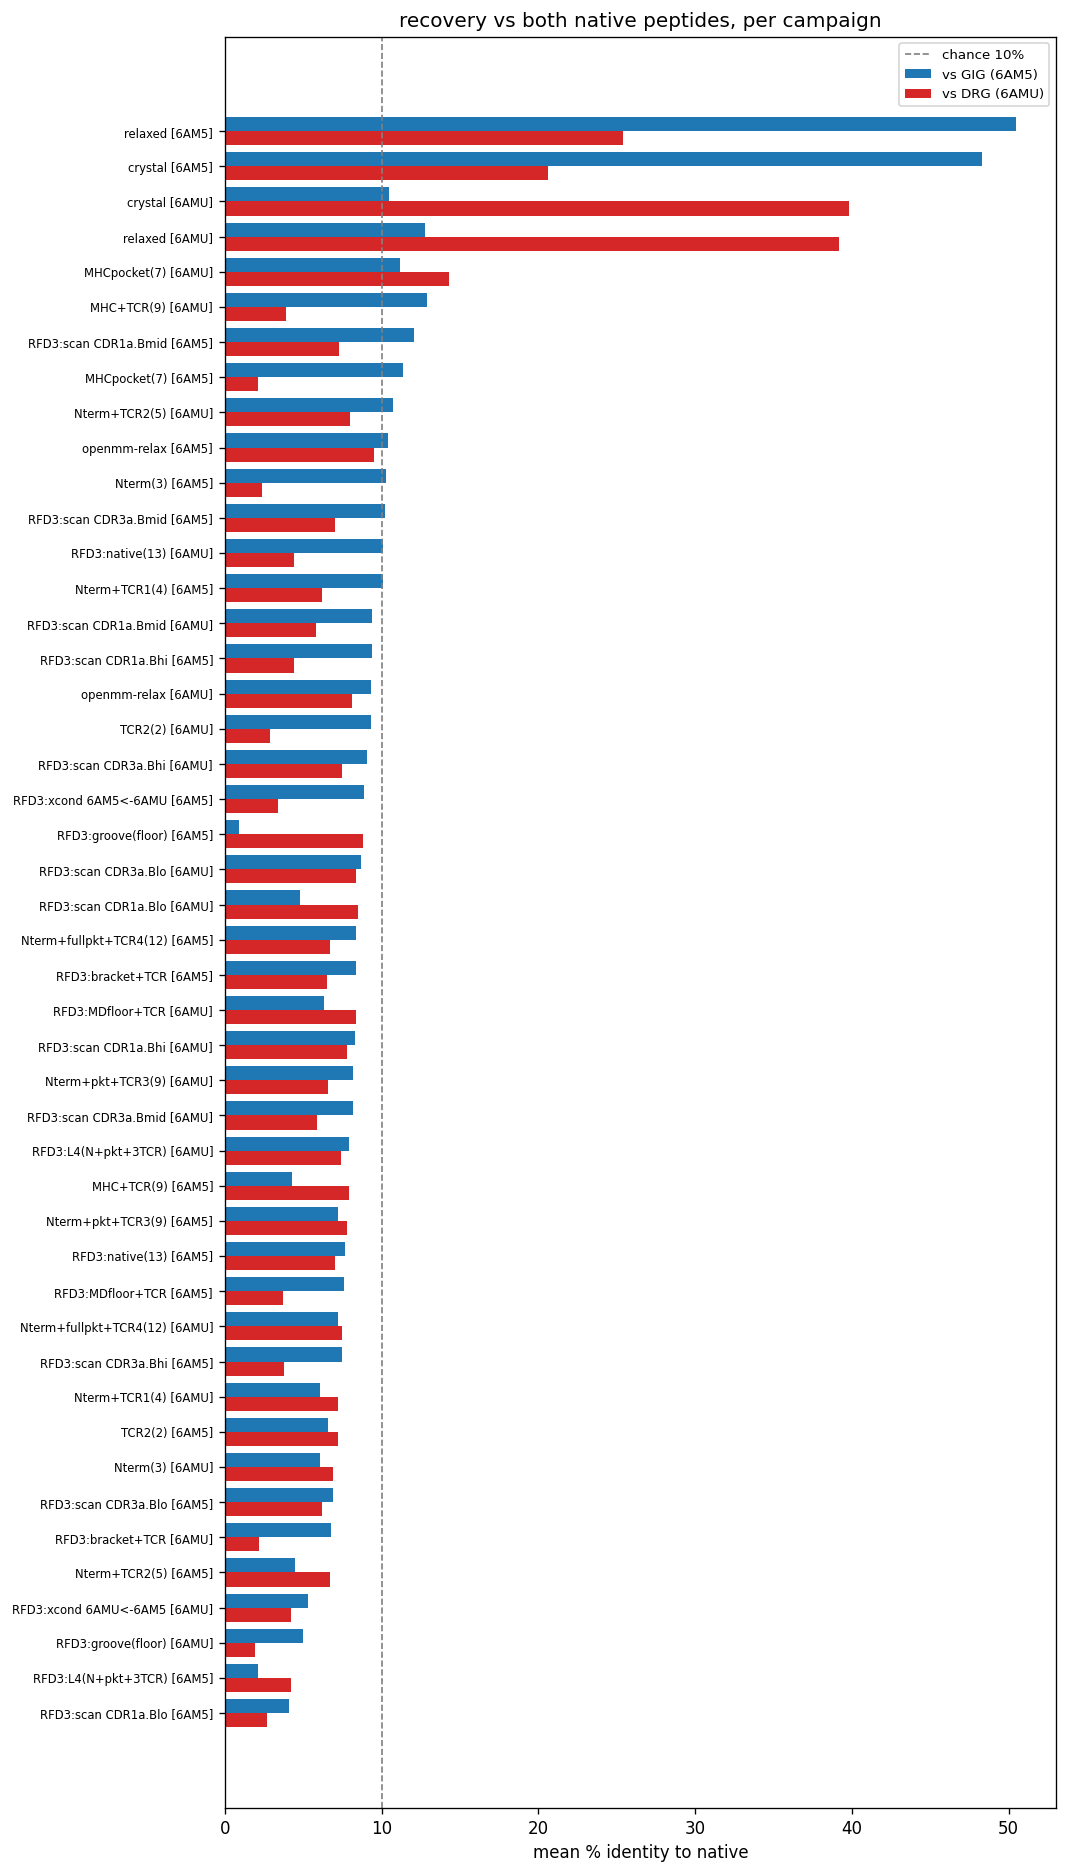

In [3]:
g=(df.groupby(["group","cond","pid"])
     .agg(n_bb=("target","nunique"),n=("peptide","size"),
          recGIG=("recGIG","mean"),recDRG=("recDRG","mean"),
          ancGIG=("ancGIG","mean"),ancDRG=("ancDRG","mean"),
          rec_cog=("rec_cog","mean"),rec_oth=("rec_oth","mean")).round(1).reset_index())
g["best_of_both"]=g[["recGIG","recDRG"]].max(axis=1)
g=g.sort_values("best_of_both",ascending=False); display(g)
fig,ax=plt.subplots(figsize=(9,0.32*len(g)+1)); y=np.arange(len(g))
ax.barh(y-0.2,g.recGIG,height=0.4,color="#1f77b4",label="vs GIG (6AM5)")
ax.barh(y+0.2,g.recDRG,height=0.4,color="#d62728",label="vs DRG (6AMU)")
ax.axvline(10,ls="--",c="0.5",lw=1,label="chance 10%")
ax.set_yticks(y); ax.set_yticklabels((g.cond+" ["+g.pid+"]").values,fontsize=7); ax.invert_yaxis()
ax.set_xlabel("mean % identity to native"); ax.set_title("recovery vs both native peptides, per campaign")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3 · Do we capture the OTHER peptide?
x = recovery vs the backbone's **cognate** epitope, y = vs the **other** epitope. Diagonal = recovers both
equally; below-right = cognate-preferring (backbone steers correctly). The dual-interface win would be points
in the **top-right** (both > chance). Table lists any campaign clearing chance on BOTH.

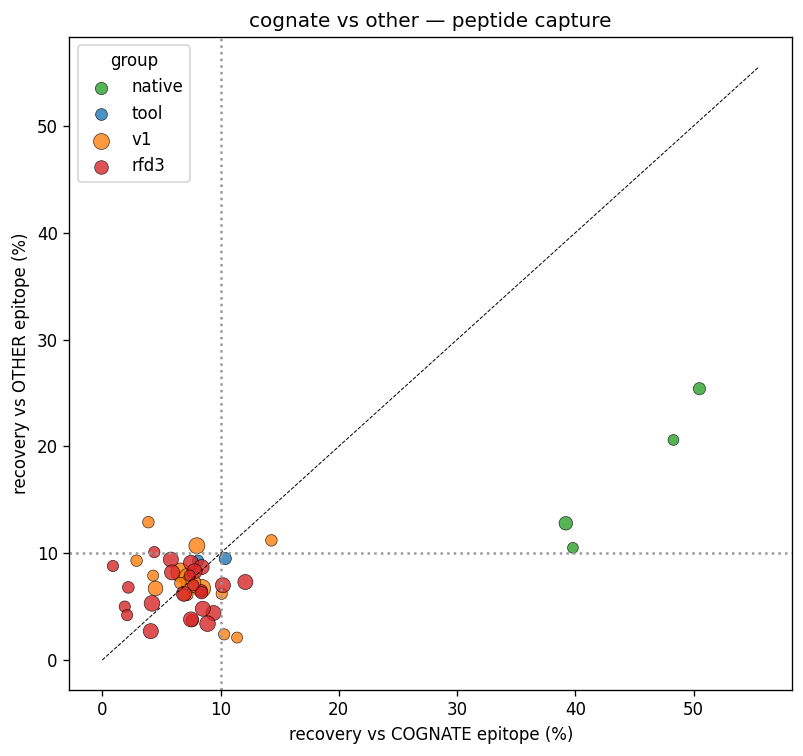

campaigns clearing chance on BOTH peptides: 5 / 46


,group,cond,pid,recGIG,recDRG,rec_cog,rec_oth
2,native,relaxed,6AM5,50.5,25.4,50.5,25.4
0,native,crystal,6AM5,48.3,20.6,48.3,20.6
3,native,relaxed,6AMU,12.8,39.2,39.2,12.8
33,v1,MHCpocket(7),6AMU,11.2,14.3,14.3,11.2
1,native,crystal,6AMU,10.5,39.8,39.8,10.5


overall cognate 10.5% vs other 8.2%


In [4]:
fig,ax=plt.subplots(figsize=(6.8,6.4))
for grp,c in GCOL.items():
    s=g[g.group==grp]
    rc=np.where(s.pid.map(PID_NATIVE)=="GIG",s.recGIG,s.recDRG)
    ro=np.where(s.pid.map(PID_NATIVE)=="GIG",s.recDRG,s.recGIG)
    ax.scatter(rc,ro,s=40+s.n_bb*2,color=c,alpha=.8,edgecolor="k",lw=.4,label=grp)
lim=max(g[["recGIG","recDRG"]].max())*1.1
ax.plot([0,lim],[0,lim],"k--",lw=.6); ax.axhline(10,ls=":",c="0.6"); ax.axvline(10,ls=":",c="0.6")
ax.set_xlabel("recovery vs COGNATE epitope (%)"); ax.set_ylabel("recovery vs OTHER epitope (%)")
ax.set_title("cognate vs other — peptide capture"); ax.legend(title="group"); plt.tight_layout(); plt.show()
both=g[(g.rec_cog>10)&(g.rec_oth>10)].sort_values("rec_oth",ascending=False)
print(f"campaigns clearing chance on BOTH peptides: {len(both)} / {len(g)}")
display(both[["group","cond","pid","recGIG","recDRG","rec_cog","rec_oth"]] if len(both) else
        pd.DataFrame({"note":["none clear 10% on both — no dual capture"]}))
print(f"overall cognate {df.rec_cog.mean():.1f}% vs other {df.rec_oth.mean():.1f}%")

## 4 · Per-residue recovery (P1…P10)
Heatmaps of per-position % match, campaigns × position, vs GIG and vs DRG. Anchors P2/PΩ boxed. This shows
*which residues* are recovered — e.g. anchor positions vs the variable core.

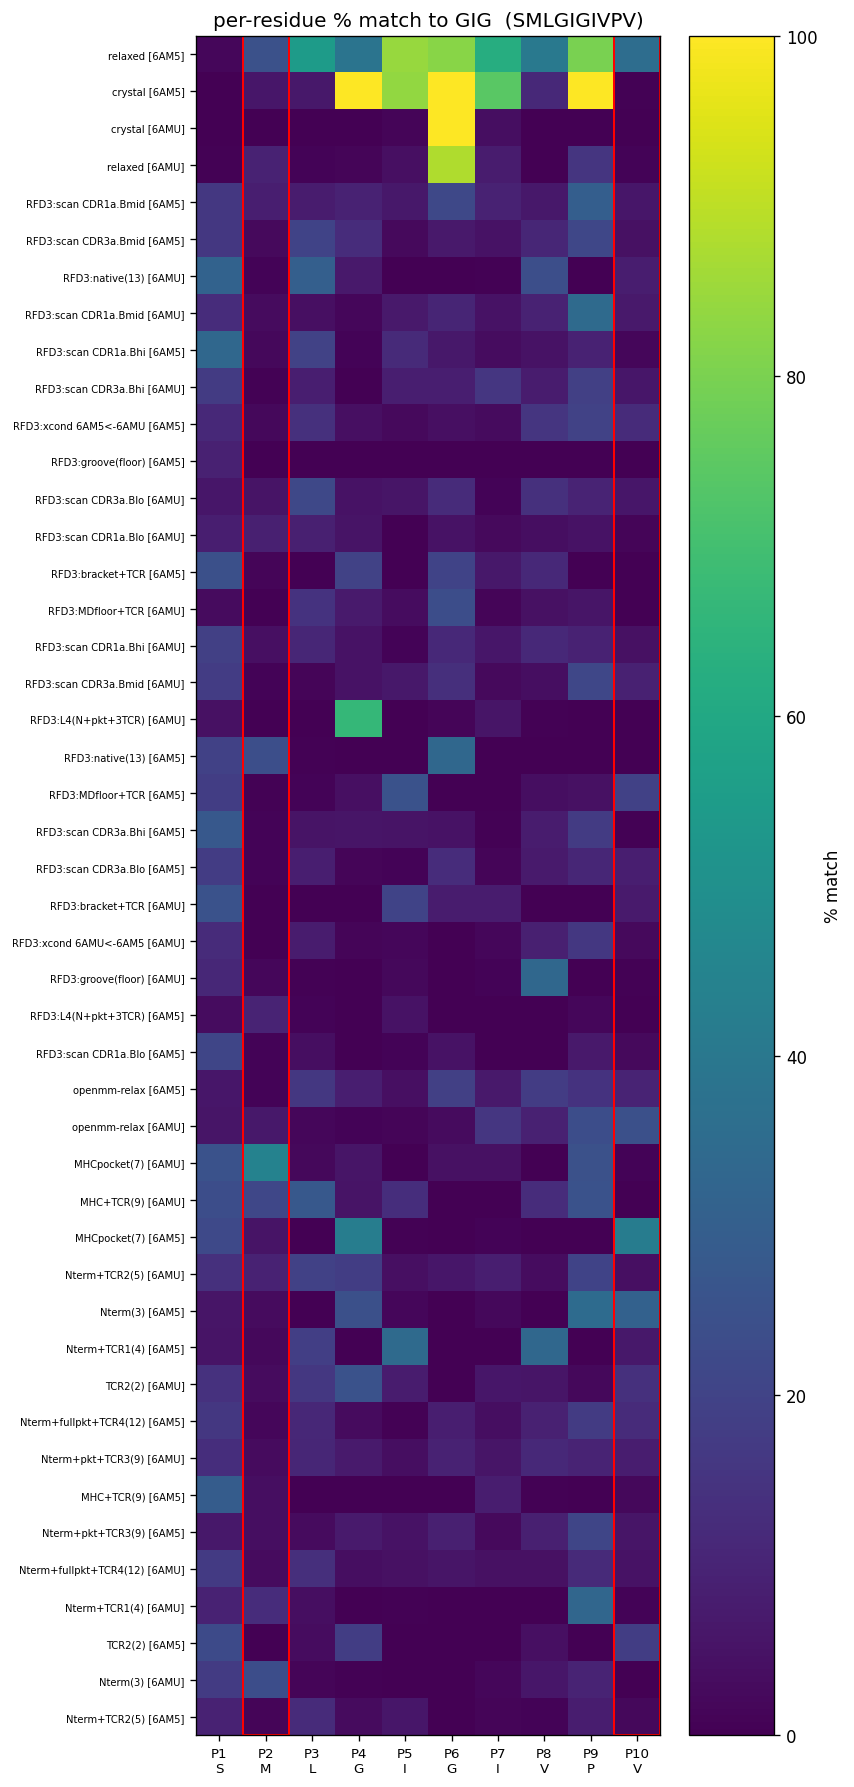

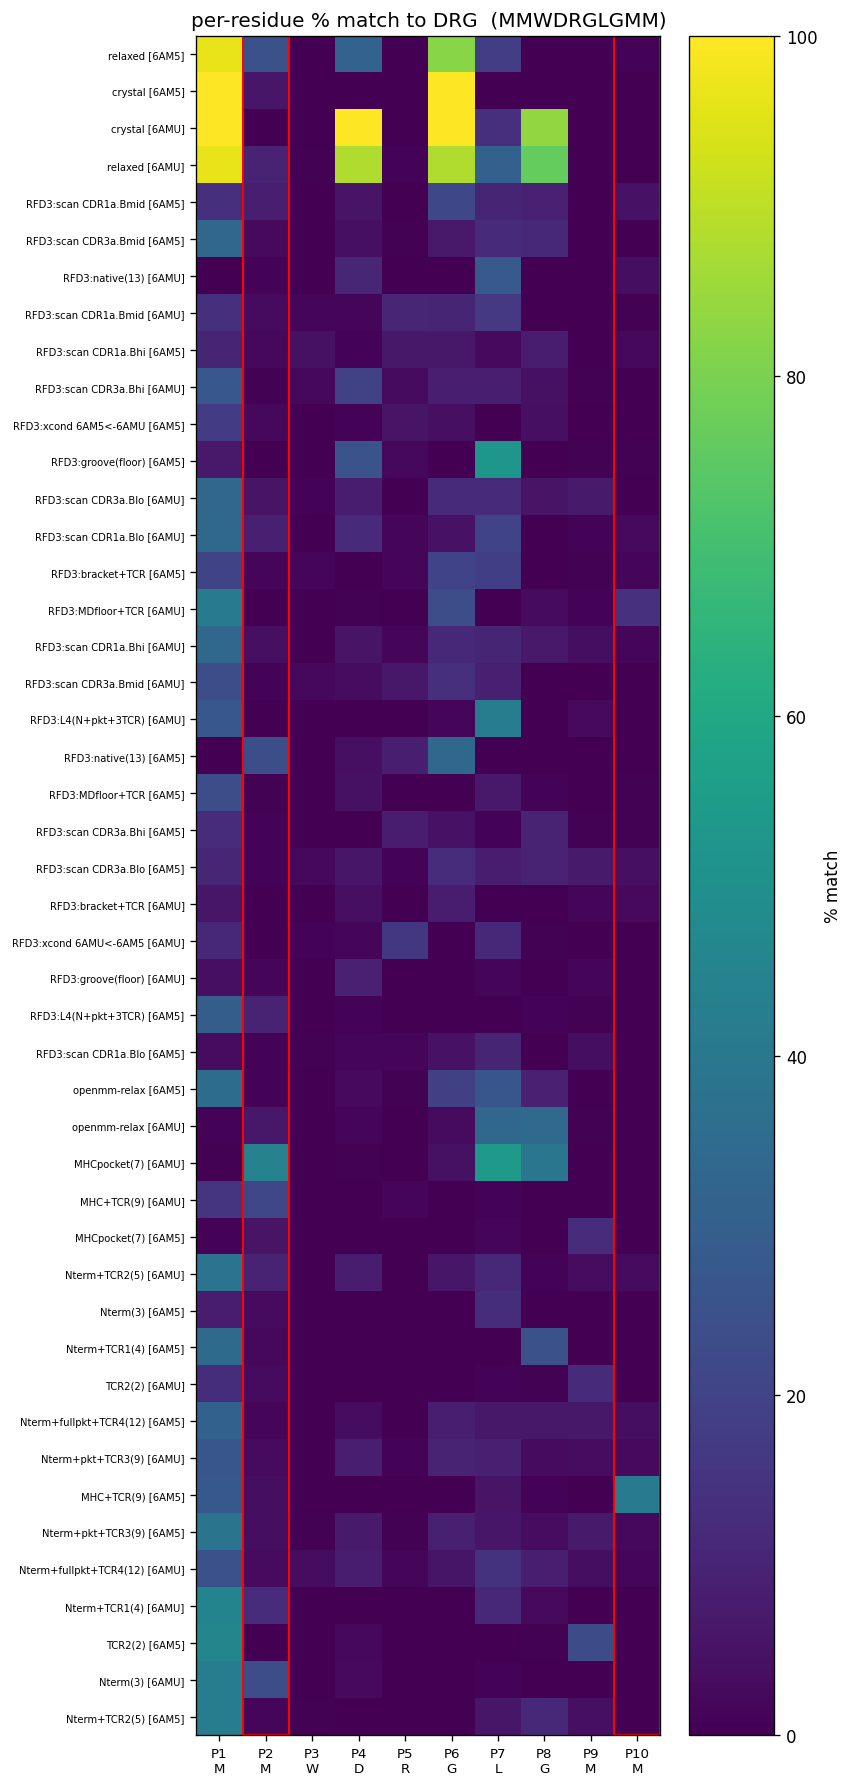

In [5]:
def perpos(sub,ref):
    Q=np.array([list(s) for s in sub.peptide]); r=np.array(list(ref))
    return (Q==r).mean(0)*100
order=g.sort_values(["group","best_of_both"],ascending=[True,False])
labels=(order.cond+" ["+order.pid+"]").values
for lab,seq in NAT.items():
    M=np.vstack([perpos(df[(df.group==r.group)&(df.cond==r.cond)&(df.pid==r.pid)],seq)
                 for _,r in order.iterrows()])
    fig,ax=plt.subplots(figsize=(7,0.30*len(M)+1.2))
    im=ax.imshow(M,aspect="auto",cmap="viridis",vmin=0,vmax=max(40,M.max()))
    ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}\n{seq[i]}" for i in range(L)],fontsize=8)
    ax.set_yticks(range(len(M))); ax.set_yticklabels(labels,fontsize=6)
    for a in ANCHORS: ax.add_patch(plt.Rectangle((a-0.5,-0.5),1,len(M),fill=False,ec="red",lw=1.2))
    ax.set_title(f"per-residue % match to {lab}  ({seq})"); plt.colorbar(im,ax=ax,label="% match")
    plt.tight_layout(); plt.show()

## 5 · Sequence-logo motif for every campaign
Native references first, then one information-content logo (unique designs) per campaign. The motif — esp.
P2/PΩ — is the read-out when exact recovery is low.

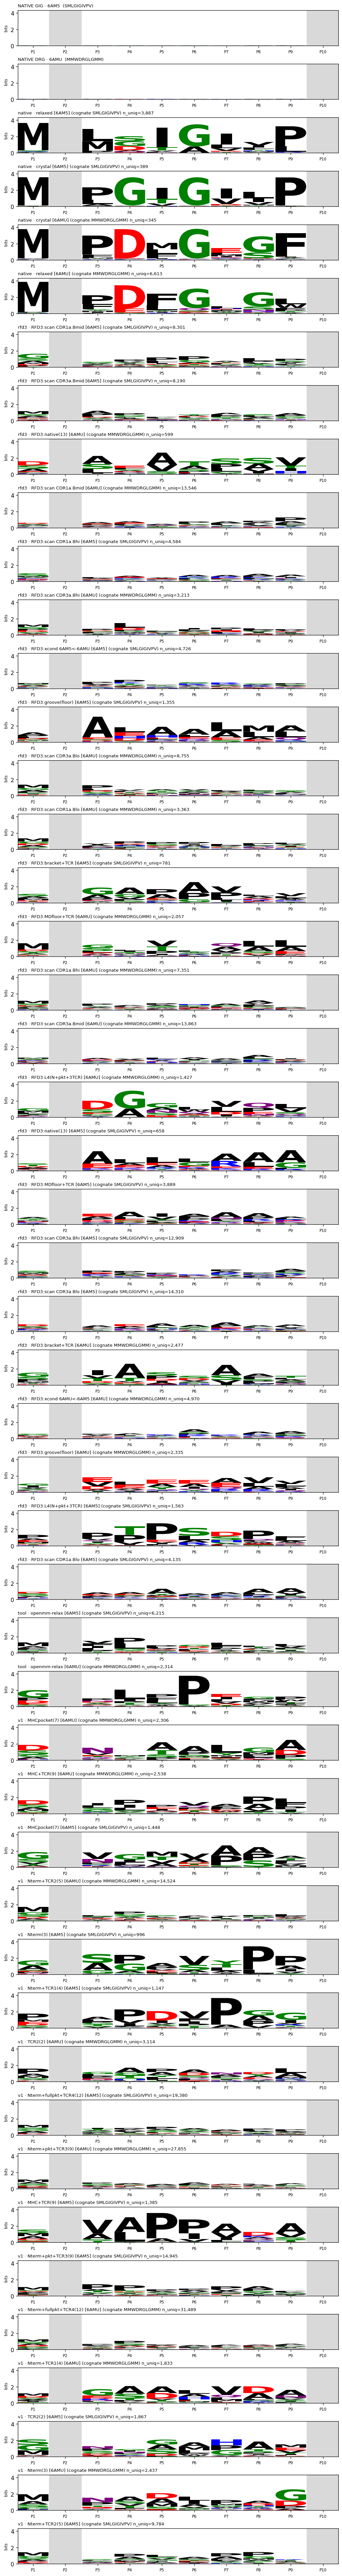

In [6]:
def draw_logo(ax,seqs,title):
    seqs=[s for s in seqs if len(s)==L]
    if not seqs: ax.set_axis_off(); ax.set_title(title+" (none)",fontsize=8,loc="left"); return
    m=logomaker.alignment_to_matrix(seqs,to_type="information",characters_to_ignore="-X").reindex(columns=AA,fill_value=0.0)
    logomaker.Logo(m,ax=ax,color_scheme="chemistry")
    for a in ANCHORS: ax.axvspan(a-0.5,a+0.5,color="0.85",zorder=0)
    ax.set_ylim(0,MAXBITS); ax.set_ylabel("bits",fontsize=7)
    ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}" for i in range(L)],fontsize=7)
    ax.set_title(title,fontsize=8,loc="left")
camps=order[["group","cond","pid"]].values.tolist()
rows=2+len(camps)
fig,axes=plt.subplots(rows,1,figsize=(8.5,1.35*rows),constrained_layout=True); i=0
for name,seq in [("GIG · 6AM5","SMLGIGIVPV"),("DRG · 6AMU","MMWDRGLGMM")]:
    draw_logo(axes[i],[seq],f"NATIVE {name}  ({seq})"); i+=1
for grp,cond,pid in camps:
    u=df[(df.group==grp)&(df.cond==cond)&(df.pid==pid)].peptide.unique().tolist()
    draw_logo(axes[i],u,f"{grp} · {cond} [{pid}] (cognate {NAT[PID_NATIVE[pid]]}) n_uniq={len(u):,}"); i+=1
plt.show()

## 5b · Closest designs per category — sorted by Hamming distance to native
For each category (design group), the unique designs with the **smallest Hamming distance** to the cognate
native epitope (0 = exact native; 10 = no shared positions), with distance to both GIG and DRG shown.

In [7]:
def hd(s,ref): return int(sum(a!=b for a,b in zip(s,ref)))
uu=df.drop_duplicates(["peptide","group","pid"])[["peptide","group","cond","pid","campaign","score"]].copy()
uu["hGIG"]=uu.peptide.map(lambda s:hd(s,NAT["GIG"])); uu["hDRG"]=uu.peptide.map(lambda s:hd(s,NAT["DRG"]))
cogn=uu.pid.map(PID_NATIVE)
uu["h_cognate"]=np.where(cogn=="GIG",uu.hGIG,uu.hDRG)
uu["h_other"]=np.where(cogn=="GIG",uu.hDRG,uu.hGIG)
TOPN=12
for cat in [c for c in ["native","tool","v1","rfd3"] if (uu.group==c).any()]:
    s=uu[uu.group==cat].sort_values(["h_cognate","score"]).head(TOPN).reset_index(drop=True)
    print(f"\n=== {cat}: top {TOPN} unique designs closest to cognate native (min Hamming) ===")
    display(s[["campaign","peptide","h_cognate","h_other","hGIG","hDRG","score"]])
print("\nmin Hamming-to-cognate per category:",
      uu.groupby("group")["h_cognate"].min().to_dict())


=== native: top 12 unique designs closest to cognate native (min Hamming) ===


,campaign,peptide,h_cognate,h_other,hGIG,hDRG,score
0,native · relaxed [6AM5],SMLGIGIVPV,0,8,0,8,1.1611
1,native · relaxed [6AM5],SLLGIGIVPV,1,9,1,9,1.1369
2,native · relaxed [6AM5],SMLGIGIIPV,1,8,1,8,1.1437
3,native · relaxed [6AM5],SMLGIGIVPL,1,8,1,8,1.1528
4,native · relaxed [6AM5],SMLDIGIVPV,1,7,1,7,1.1796
5,native · relaxed [6AM5],SMLGIGILPV,1,8,1,8,1.1840
6,native · relaxed [6AM5],MMLGIGIVPV,1,7,1,7,1.2170
7,native · relaxed [6AM5],AMLGIGIVPV,1,8,1,8,1.2306
8,native · relaxed [6AM5],HMLGIGIVPV,1,8,1,8,1.2375
9,native · relaxed [6AM5],SMLGIGIVPW,1,8,1,8,1.2711



=== tool: top 12 unique designs closest to cognate native (min Hamming) ===


,campaign,peptide,h_cognate,h_other,hGIG,hDRG,score
0,tool · openmm-relax [6AM5],SMTADTIVLV,5,9,5,9,2.0466
1,tool · openmm-relax [6AMU],PMPDFPLGTA,6,9,9,6,1.3589
2,tool · openmm-relax [6AM5],SGLLADFVPY,6,10,6,10,1.4653
3,tool · openmm-relax [6AM5],IGPGFDGVPV,6,10,6,10,1.5535
4,tool · openmm-relax [6AM5],MILGVDIPTV,6,9,6,9,1.7308
5,tool · openmm-relax [6AM5],FTFPIGPAPV,6,9,6,9,1.8622
6,tool · openmm-relax [6AM5],SIVLDTITPV,6,10,6,10,1.8744
7,tool · openmm-relax [6AM5],MSFPIGLGPV,6,6,6,6,1.9068
8,tool · openmm-relax [6AM5],ITFPIGLGPV,6,7,6,7,1.9448
9,tool · openmm-relax [6AM5],SLTLDNIVLV,6,10,6,10,1.9942



=== v1: top 12 unique designs closest to cognate native (min Hamming) ===


,campaign,peptide,h_cognate,h_other,hGIG,hDRG,score
0,v1 · Nterm+pkt+TCR3(9) [6AM5],SDLGEVLPPV,5,9,5,9,1.0270
1,v1 · Nterm+pkt+TCR3(9) [6AM5],SPLGEVLPPV,5,9,5,9,1.0327
2,v1 · Nterm+pkt+TCR3(9) [6AM5],SPLGFVLPPV,5,9,5,9,1.0709
3,v1 · Nterm+pkt+TCR3(9) [6AM5],SVLGEVLPPV,5,9,5,9,1.0856
4,v1 · Nterm+pkt+TCR3(9) [6AM5],SDLGFVLPPV,5,9,5,9,1.1088
5,v1 · Nterm+pkt+TCR3(9) [6AM5],SPLGDVLPPV,5,9,5,9,1.1122
6,v1 · Nterm+pkt+TCR3(9) [6AM5],SSLGEVLPPV,5,9,5,9,1.1136
7,v1 · Nterm+pkt+TCR3(9) [6AM5],SSLGFVLPPV,5,9,5,9,1.1214
8,v1 · Nterm+pkt+TCR3(9) [6AM5],SDLGDVLPPV,5,9,5,9,1.1392
9,v1 · Nterm+pkt+TCR3(9) [6AM5],SPLGETLPPV,5,9,5,9,1.1452



=== rfd3: top 12 unique designs closest to cognate native (min Hamming) ===


,campaign,peptide,h_cognate,h_other,hGIG,hDRG,score
0,rfd3 · RFD3:scan CDR1a.Bmid [6AM5],SALPPGIPPM,5,8,5,8,0.8504
1,rfd3 · RFD3:scan CDR3a.Bmid [6AM5],SPLGILGVGA,5,10,5,10,0.9420
2,rfd3 · RFD3:scan CDR3a.Bmid [6AM5],SPLGILGVGG,5,10,5,10,1.0335
3,rfd3 · RFD3:scan CDR1a.Bmid [6AM5],SALPPGVPPM,6,8,6,8,0.7422
4,rfd3 · RFD3:scan CDR1a.Bmid [6AM5],SPLPPGVPPM,6,8,6,8,0.7509
5,rfd3 · RFD3:scan CDR1a.Bmid [6AM5],SALPPGVPPL,6,9,6,9,0.7665
6,rfd3 · RFD3:scan CDR1a.Bmid [6AM5],SSLPPGVPPM,6,8,6,8,0.8147
7,rfd3 · RFD3:scan CDR1a.Bmid [6AM5],SAMPPGIPPM,6,8,6,8,0.8411
8,rfd3 · RFD3:scan CDR3a.Bmid [6AM5],SPLGVLGVGA,6,10,6,10,0.8554
9,rfd3 · RFD3:scan CDR3a.Bmid [6AM5],SPLGVLGVGS,6,10,6,10,0.8634



min Hamming-to-cognate per category: {'native': 0, 'rfd3': 5, 'tool': 5, 'v1': 5}


## 6 · Peptide-level distributions
Per group: distribution of recovery vs cognate/other, MPNN score, and unique-fraction (diversity).

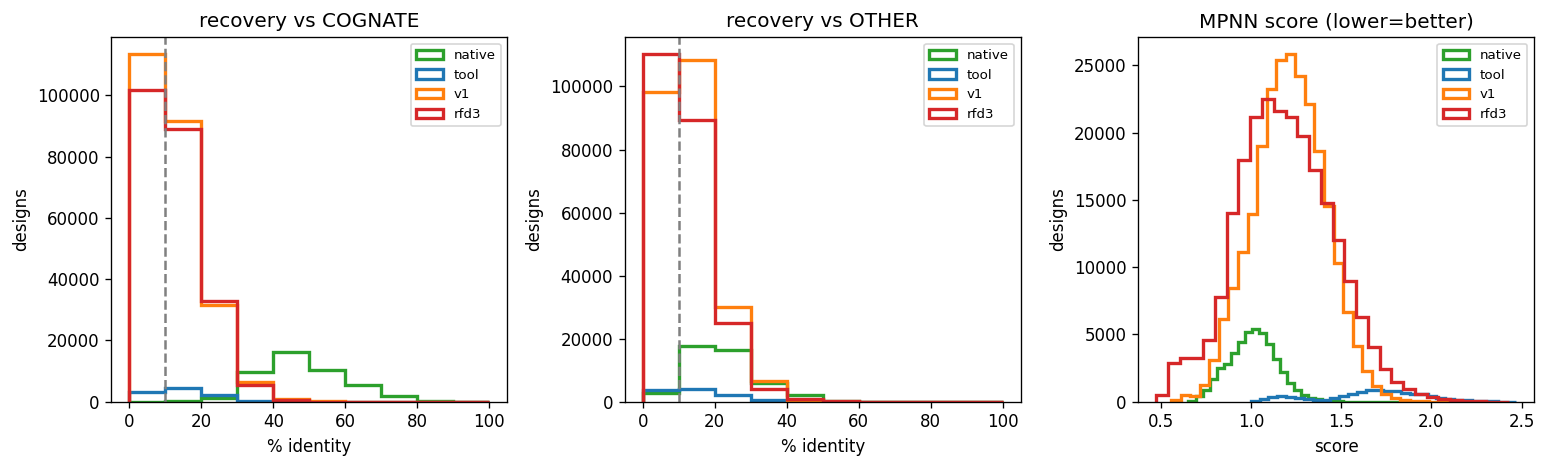

unique-fraction (sequence diversity) summary: min 0.17 | median 0.60 | max 0.87


In [8]:
groups=[x for x in ["native","tool","v1","rfd3"] if (df.group==x).any()]
fig,axes=plt.subplots(1,3,figsize=(13,4))
for grp in groups:
    s=df[df.group==grp]
    axes[0].hist(s.rec_cog,bins=np.arange(0,101,10),histtype="step",lw=2,color=GCOL[grp],label=grp)
    axes[1].hist(s.rec_oth,bins=np.arange(0,101,10),histtype="step",lw=2,color=GCOL[grp],label=grp)
    axes[2].hist(s.score.dropna(),bins=30,histtype="step",lw=2,color=GCOL[grp],label=grp)
axes[0].set_title("recovery vs COGNATE"); axes[1].set_title("recovery vs OTHER"); axes[2].set_title("MPNN score (lower=better)")
for a in axes[:2]: a.set_xlabel("% identity"); a.axvline(10,ls="--",c="0.5")
axes[2].set_xlabel("score")
for a in axes: a.set_ylabel("designs"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
# diversity per campaign
div=df.groupby("campaign").agg(n=("peptide","size"),uniq=("peptide","nunique"))
div["uniq_frac"]=(div.uniq/div.n).round(2)
print("unique-fraction (sequence diversity) summary:",
      f"min {div.uniq_frac.min():.2f} | median {div.uniq_frac.median():.2f} | max {div.uniq_frac.max():.2f}")

## 7 · Residue / amino-acid composition
Left: overall design AA frequency vs the natural AA frequency in GIG+DRG. Right: per-position AA-frequency
heatmap of all designs (★ marks the GIG residue, ● the DRG residue at each position).

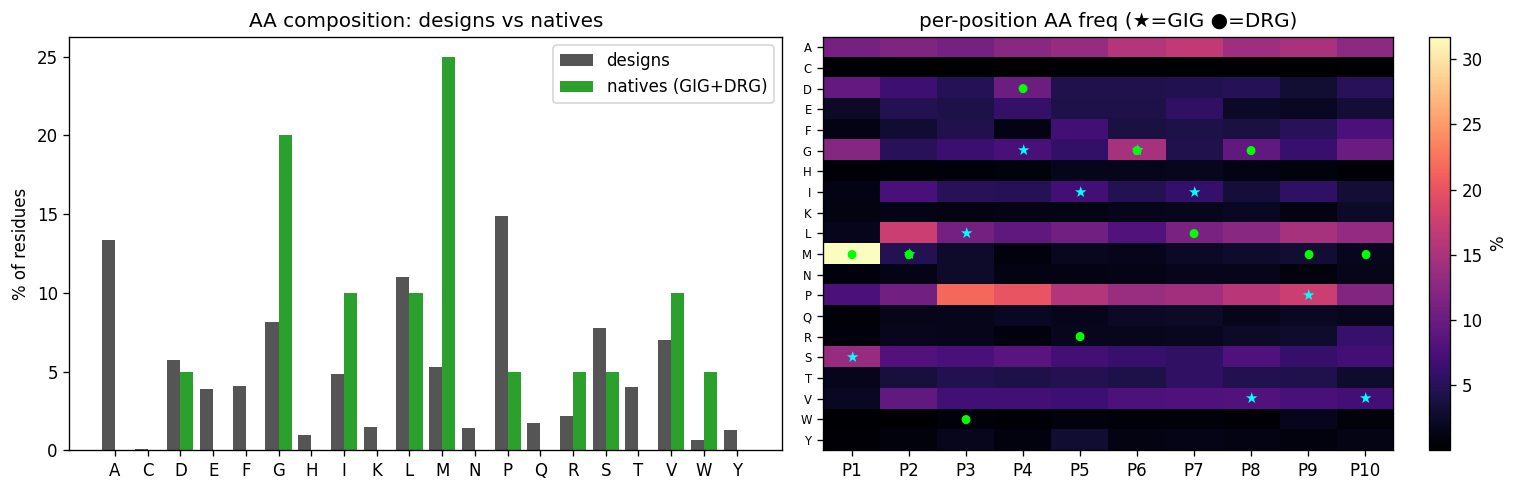

In [9]:
freq=pd.Series(P.reshape(-1)).value_counts(normalize=True).reindex(AA,fill_value=0)
nataa=pd.Series(list("SMLGIGIVPV"+"MMWDRGLGMM")).value_counts(normalize=True).reindex(AA,fill_value=0)
fig,axes=plt.subplots(1,2,figsize=(13,4.2))
x=np.arange(len(AA))
axes[0].bar(x-0.2,freq.values*100,width=0.4,label="designs",color="#555")
axes[0].bar(x+0.2,nataa.values*100,width=0.4,label="natives (GIG+DRG)",color="#2ca02c")
axes[0].set_xticks(x); axes[0].set_xticklabels(AA); axes[0].set_ylabel("% of residues")
axes[0].set_title("AA composition: designs vs natives"); axes[0].legend()
comp=np.zeros((len(AA),L))
for j in range(L):
    vc=pd.Series(P[:,j]).value_counts(normalize=True)
    for k,a in enumerate(AA): comp[k,j]=vc.get(a,0)*100
im=axes[1].imshow(comp,aspect="auto",cmap="magma")
axes[1].set_yticks(range(len(AA))); axes[1].set_yticklabels(AA,fontsize=7)
axes[1].set_xticks(range(L)); axes[1].set_xticklabels([f"P{i+1}" for i in range(L)])
for j,(gg,dd) in enumerate(zip("SMLGIGIVPV","MMWDRGLGMM")):
    axes[1].text(j,AA.index(gg),"★",ha="center",va="center",color="cyan",fontsize=9)
    axes[1].text(j,AA.index(dd),"●",ha="center",va="center",color="lime",fontsize=7)
axes[1].set_title("per-position AA freq (★=GIG ●=DRG)"); plt.colorbar(im,ax=axes[1],label="%")
plt.tight_layout(); plt.show()

## 8 · Structural distributions
Where each campaign's backbones sit relative to the two native peptide basins (register-preserving Cα-RMSD),
and the peptide-CA backbone traces in the common groove frame (from `core_load`). Stars = native GIG/DRG.

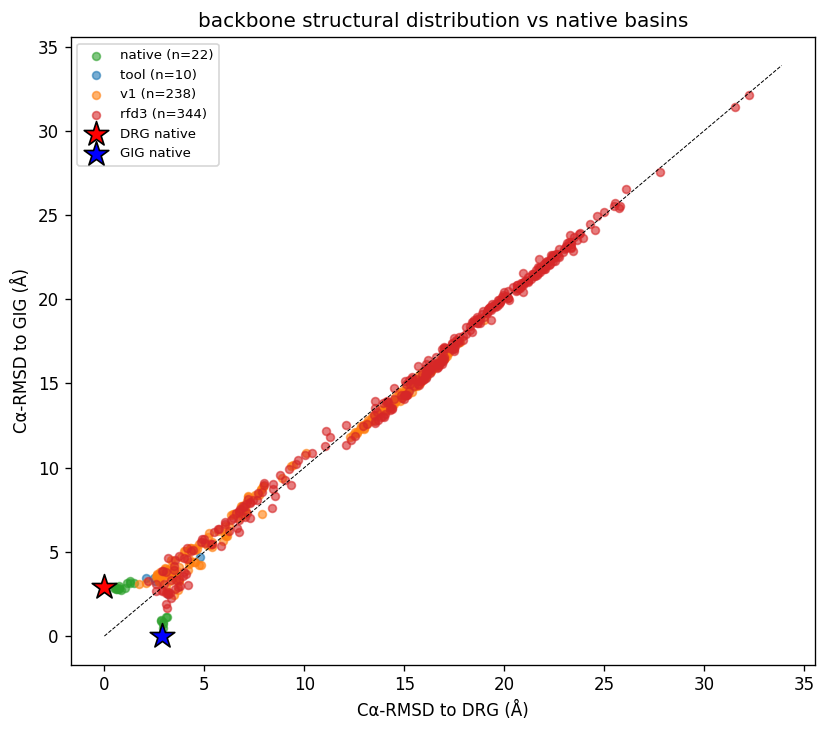

In [10]:
# dual-RMSD plane from the per-design table (one point per backbone)
bb=df.drop_duplicates("target")
fig,ax=plt.subplots(figsize=(7,6.2))
for grp,c in GCOL.items():
    s=bb[bb.group==grp]; ax.scatter(s.toDRG,s.toGIG,s=22,alpha=.6,color=c,label=f"{grp} (n={len(s)})")
lim=np.nanmax([bb.toDRG.max(),bb.toGIG.max()])*1.05
ax.plot([0,lim],[0,lim],"k--",lw=.6)
ax.scatter([0],[2.9],marker="*",s=240,color="red",ec="k",label="DRG native"); ax.scatter([2.9],[0],marker="*",s=240,color="blue",ec="k",label="GIG native")
ax.set_xlabel("Cα-RMSD to DRG (Å)"); ax.set_ylabel("Cα-RMSD to GIG (Å)")
ax.set_title("backbone structural distribution vs native basins"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

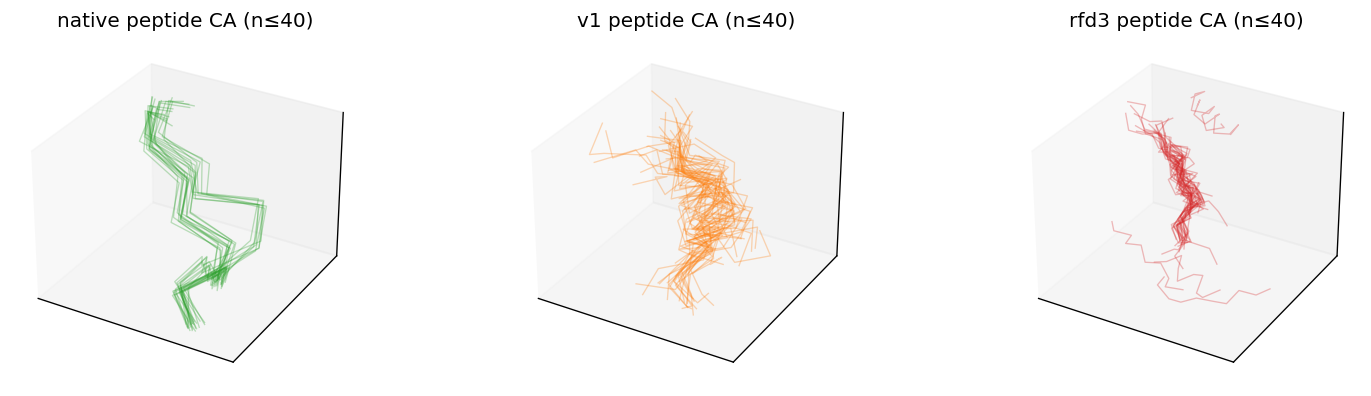

structural traces from outputs/struct_ood/core_cache


In [11]:
# peptide CA traces in common frame (optional; from core_load cache)
try:
    CACHE=f"{ROOT}/outputs/struct_ood/core_cache"
    cdf=pd.read_parquet(f"{CACHE}/df.parquet"); CO=np.load(f"{CACHE}/coords.npy")
    fig=plt.figure(figsize=(13,3.4));
    for k,grp in enumerate(["native","v1","rfd3"]):
        ax=fig.add_subplot(1,3,k+1,projection="3d"); idx=cdf.index[cdf.group==grp]
        for i in idx[:40]:
            p=CO[i]; ax.plot(p[:,0],p[:,1],p[:,2],color=GCOL[grp],alpha=.3,lw=.8)
        ax.set_title(f"{grp} peptide CA (n≤40)"); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    plt.tight_layout(); plt.show()
    print("structural traces from", os.path.relpath(CACHE,ROOT))
except Exception as e:
    print("peptide-CA traces unavailable:",e)

## 9 · Summary

In [12]:
best=g.iloc[0]; worst=g.iloc[-1]
print(f"data: {os.path.relpath(CSV,ROOT)} | designs {len(df):,} | depth med {int(depth.median())}/struct")
print(f"overall: cognate {df.rec_cog.mean():.1f}% | other {df.rec_oth.mean():.1f}% | cognate-anchor {df.anc_cog.mean():.1f}% (chance ~10%)")
print(f"best campaign : {best.cond} [{best.pid}]  GIG {best.recGIG}% DRG {best.recDRG}% (n_bb {int(best.n_bb)})")
print(f"worst campaign: {worst.cond} [{worst.pid}]  GIG {worst.recGIG}% DRG {worst.recDRG}%")
nat=df[df.group=="native"]
if len(nat): print(f"near-native backbones: cognate {nat.rec_cog.mean():.1f}% vs other {nat.rec_oth.mean():.1f}%  -> {nat.rec_cog.mean()/max(nat.rec_oth.mean(),1e-9):.1f}x steering")
both=g[(g.rec_cog>10)&(g.rec_oth>10)]
print(f"dual-capture campaigns (both peptides > chance): {len(both)}")
for grp in ["v1","rfd3"]:
    s=df[df.group==grp]
    if len(s): print(f"{grp}: cognate {s.rec_cog.mean():.1f}% vs other {s.rec_oth.mean():.1f}%")

data: outputs/mpnn_nomhc_allbb_deep/designs_deep.csv | designs 528,750 | depth med 1024/struct
overall: cognate 10.5% | other 8.2% | cognate-anchor 4.8% (chance ~10%)
best campaign : relaxed [6AM5]  GIG 50.5% DRG 25.4% (n_bb 7)
worst campaign: RFD3:scan CDR1a.Blo [6AM5]  GIG 4.1% DRG 2.7%
near-native backbones: cognate 43.2% vs other 17.1%  -> 2.5x steering
dual-capture campaigns (both peptides > chance): 5
v1: cognate 7.3% vs other 7.8%
rfd3: cognate 7.5% vs other 6.8%
